<a href="https://colab.research.google.com/github/saad0O5/FlyRank-Internship-Work/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saad0O5/FlyRank-s-Project/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Which pages should a content/SEO reviewer look at first, out of a large
inventory, when review time is limited?

**Decision this supports:** prioritizing a reviewer's limited weekly capacity toward pages most
likely to be genuinely declining over the next 30 days — so review effort isn't spent randomly
or on intuition alone. A wrong call costs either wasted reviewer time (false positive) or a real
declining page going unreviewed (false negative). Because the reviewer only ever works through
the top of a ranked list, the success metric is Precision@K, not overall accuracy (established in
w01/w03).

## 2. Data

**Release:** FlyRank/internship-warehouse (Hugging Face, build v20260703).
**Tables used:** `fact_content_daily_performance` (daily x client x content) and `dim_clients`
(for history-depth checks).
**Feature window:** 2025-12-31 to 2026-03-31 (90 days).
**Label window:** 2026-04-01 to 2026-04-30 (30 days, strictly after the feature window —
verified with an assertion in w03 to rule out overlap).
**Rows:** 115,617 content items after filtering to `imp_prev90 >= 100`.

**Excluded, and why:**
- `fact_content_query_90d` — found (w03) to be a single fixed window (2026-04-02 to
  2026-06-30), not month-aligned. That window overlaps and postdates the label window, so its
  fields (`visible_queries`, `rare_share`) would leak future information. Not obvious from the
  schema alone — only caught by directly checking `window_start`/`window_end`.
- Any FlyRank product-computed field (`health_score`, `priority_score`, `action_type`) — not
  shipped in the release, and excluded on principle to avoid a circular result if ever rebuilt.
- GA4-derived fields — excluded from this model, since only 4.2% of March rows have
  `ga4_data_available = TRUE` in this slice.
- No client names, domains, URLs, or raw queries appear anywhere in this data or this paper —
  all IDs are pseudonymized hashes used only for grouping and joins.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [5]:
import duckdb, pandas as pd, numpy as np, os, getpass

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute("PRAGMA threads=1")   # deterministic aggregation — fixed a reproducibility bug in w06
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {'fact_daily': f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"}

feat = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS imp_prev90,
           SUM(gsc_clicks)      AS clk_prev90,
           AVG(gsc_avg_position) AS pos_avg_prev90,
           SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0) AS ctr_prev90,
           COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_active_prev90
    FROM {TABLES['fact_daily']}
    WHERE report_date BETWEEN '2025-12-31' AND '2026-03-31'
    GROUP BY 1, 2
    HAVING imp_prev90 >= 100
    ORDER BY client_hash_id, content_hash_id
""").df()

label = con.sql(f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_impressions) AS imp_next30
    FROM {TABLES['fact_daily']}
    WHERE report_date BETWEEN '2026-04-01' AND '2026-04-30'
    GROUP BY 1, 2
    ORDER BY client_hash_id, content_hash_id
""").df()

data = feat.merge(label, on=['client_hash_id', 'content_hash_id'], how='inner')
data['is_declining_future'] = (data['imp_next30'] < 0.8 * (data['imp_prev90'] / 3)).astype(int)
print(f"{len(data):,} rows, decline rate {data['is_declining_future'].mean():.3f}")

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

115,617 rows, decline rate 0.371


**Label:** `is_declining_future` — impressions in the 30-day label window fall below 80% of the
feature window's average 30-day pace. A genuine future outcome (fixed after w01/w02's lesson
that the starter dataset's `trend_direction` was only a current-state bucket, not a forecast).

**Baseline:** a tier-adjusted CTR gap (w04) — a page's CTR compared to its own position tier's
average, not a raw CTR floor. A raw floor was rejected after Week 1's Lane 4 exploration showed
it collapses into a large tied block of zero-CTR pages with no real ordering.

**Model:** Random Forest (200 trees). Chosen because Week 2's decision-tree experiments on the
starter data showed the underlying signals are tangled and non-linear — a tree ensemble
combines them without hand-built interaction terms, while staying interpretable via feature
importances.

**Validation design:** client-grouped split (GroupShuffleSplit on `client_hash_id`) — pages from
one client never appear in both train and test. Chosen because Week 1 showed decline rate varies
0%–93.7% by client; a random split risks the model memorizing client-level quirks instead of
learning a generalizable pattern.

**Leakage checks:** a deliberate leak test (adding `imp_next30`, the label-derived column, as a
feature) pushed AUC to 0.999, confirming the audit process works, before it was removed. The
final feature set (`imp_prev90`, `clk_prev90`, `pos_avg_prev90`, `ctr_prev90`,
`days_active_prev90`) is computed strictly within the feature window, with no dates after
2026-03-31.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

feature_cols = ['imp_prev90', 'clk_prev90', 'pos_avg_prev90', 'ctr_prev90', 'days_active_prev90']
model_data = data.dropna(subset=feature_cols + ['is_declining_future'])
X, y, groups = model_data[feature_cols], model_data['is_declining_future'], model_data['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1).fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]

def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-scores)[:k]
    return y_true.iloc[order].mean()

p50 = precision_at_k(y_te, proba, k=50)
auc = roc_auc_score(y_te, proba)

test_slice = model_data.loc[X_te.index].copy()
test_slice['position_tier'] = pd.cut(test_slice['pos_avg_prev90'], bins=[0,3,10,20,9999], labels=['1-3','4-10','11-20','21+'])
tier_avg = model_data.assign(
    position_tier=pd.cut(model_data['pos_avg_prev90'], bins=[0,3,10,20,9999], labels=['1-3','4-10','11-20','21+'])
).groupby('position_tier', observed=True)['ctr_prev90'].transform('mean')
test_slice['ctr_gap'] = (tier_avg.loc[X_te.index] - test_slice['ctr_prev90']).clip(lower=0)
base_p50 = precision_at_k(y_te, test_slice['ctr_gap'].values, k=50)

print(f"{'Method':<20}{'Precision@50':>15}{'AUC':>10}")
print(f"{'Baseline (rule)':<20}{base_p50:>15.3f}{'—':>10}")
print(f"{'Random Forest':<20}{p50:>15.3f}{auc:>10.3f}")
print(f"\nLift: {p50/base_p50:.1f}x")

Method                 Precision@50       AUC
Baseline (rule)               0.340         —
Random Forest                 0.680     0.720

Lift: 2.0x


| Method | Precision@50 | AUC |
|---|---|---|
| Baseline (tier-adjusted CTR rule) | 0.340 | — |
| Random Forest | 0.680 | 0.720 |

A 2.0x lift on a client-grouped holdout — pages from clients never seen in training. This result
was re-checked for reproducibility after an early run showed unstable numbers between identical
executions; the cause was DuckDB's default multi-threaded, non-deterministic row order, fixed
with `PRAGMA threads=1`. A naive (ungrouped) random split was also tested as a comparison and
produced a similar number (0.660) in this snapshot — smaller inflation than expected, reported
honestly rather than omitted.

## 5. Limitations

- **One snapshot in time** (Dec 2025 features → Apr 2026 outcome). The lift is not yet validated
  on a different month or after a real seasonal shift.
- **Per-client calibration varies** — some clients are systematically over-predicted, one is
  under-predicted. This queue is not equally reliable for every client without a calibration step.
- **Decision-support, not causal.** A "review" flag means "worth a reviewer's time," not "will
  decline" and not "refreshing this page will cause it to recover" — no controlled experiment
  was run to support a causal claim.
- **Not a claim about Google's algorithm.** This model describes observed, historical
  associations in FlyRank's own tracked search performance data — it does not reverse-engineer
  or predict any search engine's ranking system.
- The label (`is_declining_future`) is one reasonable definition of decline among several
  possible thresholds; a different magnitude or window choice could shift results.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [7]:
model_data['risk_score'] = model.predict_proba(model_data[feature_cols])[:, 1]

def assign_reason_code(row):
    if row['risk_score'] >= 0.65:
        return 'model_high_decline_risk'
    elif row['pos_avg_prev90'] <= 20 and row['ctr_prev90'] == 0:
        return 'visible_zero_ctr'
    elif row['days_active_prev90'] < 10 and row['imp_prev90'] < 200:
        return 'low_data_new_page'
    else:
        return 'routine_monitor'

model_data['reason_code'] = model_data.apply(assign_reason_code, axis=1)

REVIEW_CAPACITY, WATCH_CAPACITY = 200, 1000
queue = model_data.sort_values('risk_score', ascending=False).reset_index(drop=True)

def assign_action(i, reason_code):
    if reason_code == 'low_data_new_page':
        return 'monitor_only'
    elif i < REVIEW_CAPACITY:
        return 'review'
    elif i < WATCH_CAPACITY:
        return 'watch'
    return 'no_action'

queue['action'] = [assign_action(i, rc) for i, rc in enumerate(queue['reason_code'])]
print(queue['action'].value_counts())

action
no_action       114319
watch              800
monitor_only       298
review             200
Name: count, dtype: int64


**Action playbook:** 200 pages flagged `review` (top-ranked, realistic reviewer capacity per
cycle), 800 `watch` (secondary tier), 298 `monitor_only` (new pages the model deliberately
declines to score confidently, since low-activity pages trend toward growth, not decline — a
disproven assumption caught in w04), and the remainder `no_action`. `no_action` means "not
flagged in this snapshot," not "independently verified healthy."

Before acting on any flagged page, a reviewer should check: whether it's genuinely new rather
than declining; whether a `visible_zero_ctr` flag reflects a real problem or a SERP feature
(e.g. a featured snippet) suppressing clicks; and whether the page belongs to a client known to
be miscalibrated (Section 5).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

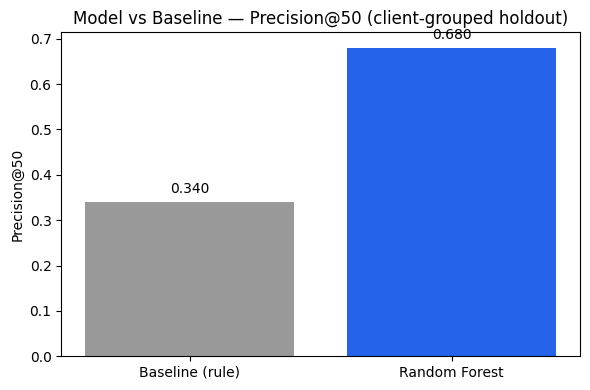

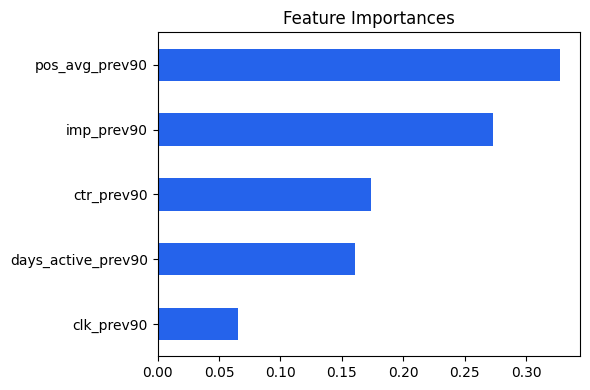

Saved: precision_comparison.png, feature_importances.png, final_action_queue.csv


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Baseline (rule)', 'Random Forest'], [base_p50, p50], color=['#999', '#2563eb'])
ax.set_ylabel('Precision@50')
ax.set_title('Model vs Baseline — Precision@50 (client-grouped holdout)')
for i, v in enumerate([base_p50, p50]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
os.makedirs('work/outputs/charts', exist_ok=True)
plt.savefig('work/outputs/charts/precision_comparison.png', dpi=150)
plt.show()

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
fig2, ax2 = plt.subplots(figsize=(6,4))
importances.plot(kind='barh', ax=ax2, color='#2563eb')
ax2.set_title('Feature Importances')
plt.tight_layout()
plt.savefig('work/outputs/charts/feature_importances.png', dpi=150)
plt.show()

queue.to_csv('work/outputs/final_action_queue.csv', index=False)
print("Saved: precision_comparison.png, feature_importances.png, final_action_queue.csv")

### 5-minute demo outline
1. (30s) The problem: a reviewer can't check every page — which to prioritize?
2. (1 min) The data: FlyRank's real search warehouse, one snapshot, leakage-checked labels.
3. (1.5 min) Show the baseline (tier-adjusted CTR rule) vs the model, side by side — the chart.
4. (1 min) Walk through one flagged page from the top-20 and its reason code.
5. (1 min) Limitations, stated plainly — one snapshot, per-client calibration caveat, decision-
   support not causal.

### Social-post cut
"Built a content-review prioritization model on 115K real (anonymized) search pages: a
client-grouped Random Forest beats a transparent baseline rule 2x at flagging pages likely to
decline next month (Precision@50: 0.68 vs 0.34). Full write-up + honest limitations here: [link]
#MachineLearning #SEO #DataScience"

### 3-sentence employer-facing summary
Built and validated a machine learning pipeline that ranks website content by decline risk using
real (anonymized) Google Search Console data, achieving a 2x precision lift over a transparent
rule-based baseline on a properly held-out test set. Along the way, identified and fixed two
data-leakage risks and a reproducibility bug in the underlying query engine — treating validation
rigor as a first-class deliverable, not an afterthought. Delivered as a reproducible notebook
pipeline plus a public research paper with clearly stated limitations and decision-support (not
causal) framing.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
